**Install Required Packages**

In [1]:
!pip install tensorflow
!pip install scikit-learn
!pip install onnx
!pip install onnxruntime
!pip install tf2onnx
!pip install skl2onnx
!pip install matplotlib seaborn pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 8.0 MB/s eta 0:00:00


**Load MNIST Dataset**

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = \
    tf.keras.datasets.mnist.load_data()

print(x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)


# **Visualize MNIST Samples**

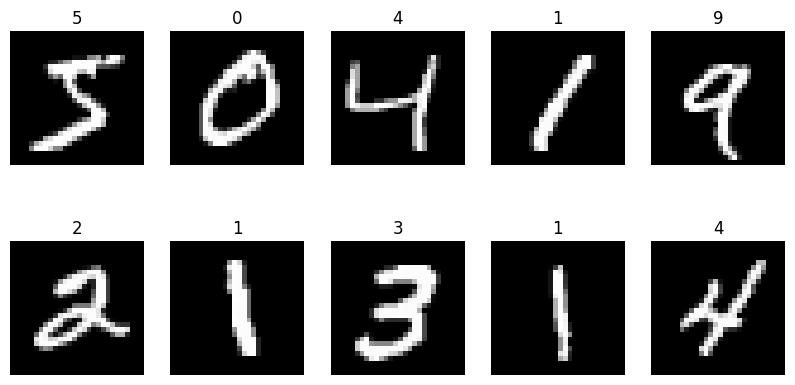

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(str(y_train[i]))
    plt.axis("off")

plt.show()

**Preprocessing**


In [4]:
# For Machine Learning

import numpy as np

x_train_ml = x_train.reshape(60000, 784)
x_test_ml = x_test.reshape(10000, 784)

In [5]:
#For Deep Learning

x_train_dl = x_train.astype("float32") / 255.0
x_test_dl = x_test.astype("float32") / 255.0

x_train_dl = x_train_dl.reshape(-1,28,28,1)
x_test_dl = x_test_dl.reshape(-1,28,28,1)

**Machine Learning Model (Random Forest)**

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train_ml, y_train)

RandomForestClassifier(random_state=42)

In [7]:
# Prediction:
rf_pred = rf.predict(x_test_ml)

In [8]:
# Accuracy:

from sklearn.metrics import accuracy_score

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(rf_acc)

0.9705


# **Convert Random Forest → ONNX**

In [9]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

initial_type = [
    ('float_input',
     FloatTensorType([None, 784]))
]

onnx_model = convert_sklearn(
    rf,
    initial_types=initial_type
)

with open("rf_mnist.onnx","wb") as f:
    f.write(onnx_model.SerializeToString())

**ONNX Runtime for Random Forest**

In [10]:
import onnxruntime as ort

session = ort.InferenceSession(
    "rf_mnist.onnx"
)

input_name = session.get_inputs()[0].name

pred = session.run(
    None,
    {
      input_name:
      x_test_ml[:1].astype(np.float32)
    }
)

# **Deep Learning Model (Keras CNN)**

In [11]:
from tensorflow.keras import layers
from tensorflow.keras import models

cnn = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Compile
cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
# Train
history = cnn.fit(
    x_train_dl,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9589 - loss: 0.1340 - val_accuracy: 0.9862 - val_loss: 0.0449
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9857 - loss: 0.0461 - val_accuracy: 0.9892 - val_loss: 0.0384
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9898 - loss: 0.0309 - val_accuracy: 0.9885 - val_loss: 0.0415
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9931 - loss: 0.0223 - val_accuracy: 0.9903 - val_loss: 0.0352
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9946 - loss: 0.0170 - val_accuracy: 0.9887 - val_loss: 0.0392


# **CNN Training Visualization**

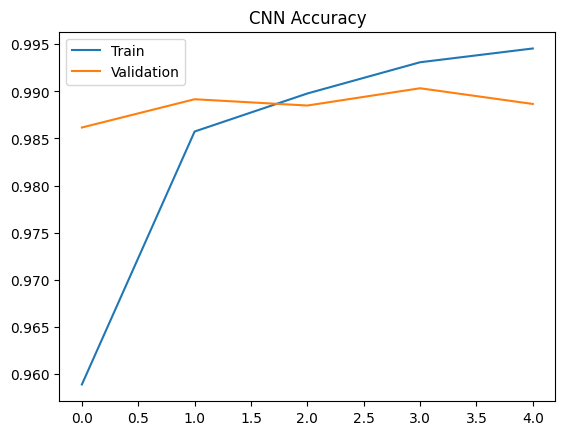

In [14]:
plt.plot(
    history.history["accuracy"]
)

plt.plot(
    history.history["val_accuracy"]
)

plt.legend(["Train","Validation"])
plt.title("CNN Accuracy")
plt.show()

In [15]:
# CNN Evaluation
cnn_loss, cnn_acc = cnn.evaluate(
    x_test_dl,
    y_test
)

print(cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9893 - loss: 0.0334
0.989300012588501


# **Convert CNN → ONNX**

In [16]:
import tensorflow as tf
import tf2onnx

print("TensorFlow:", tf.__version__)
print("tf2onnx:", tf2onnx.__version__)

TensorFlow: 2.20.0
tf2onnx: 1.17.0


In [17]:
import tf2onnx

print(dir(tf2onnx.convert))

['ExternalTensorStorage', 'Version', '_HELP_TEXT', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_convert_common', '_from_keras_tf1', '_get_concrete_function', '_get_input_names', '_get_output_names', '_is_legacy_keras_model', '_rename_duplicate_keras_model_names', '_set_output_names', 'argparse', 'compress_graph_def', 'constants', 'from_function', 'from_graph_def', 'from_keras', 'from_tflite', 'get_args', 'get_tf_version', 'logging', 'main', 'make_default_custom_op_handler', 'optimizer', 'os', 'process_tf_graph', 'sys', 'tensor_names_from_structed', 'tf', 'tf_loader', 'utils']


In [18]:
import tensorflow as tf

@tf.function
def model_fn(x):
    return cnn(x)

import tf2onnx

onnx_model, _ = tf2onnx.convert.from_function(
    model_fn,
    input_signature=[
        tf.TensorSpec(
            [None, 28, 28, 1],
            tf.float32,
            name="input"
        )
    ],
    opset=13
)

with open("cnn_mnist.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

# **CNN ONNX Runtime Inference**

In [19]:
session = ort.InferenceSession(
    "cnn_mnist.onnx"
)

input_name = session.get_inputs()[0].name

pred = session.run(
    None,
    {
        input_name:
        x_test_dl[:1].astype(np.float32)
    }
)

# **Confusion Matrix Comparison**

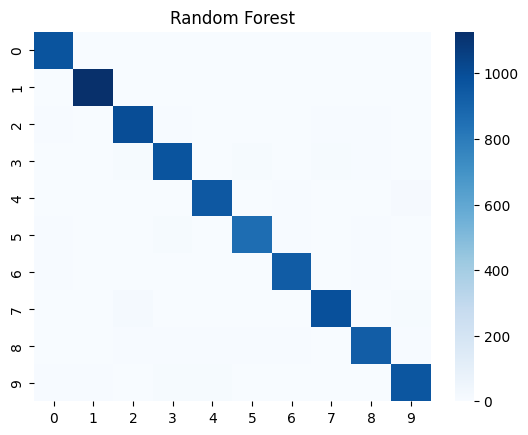

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    rf_cm,
    cmap="Blues"
)

plt.title(
    "Random Forest"
)

plt.show()

# **Benchmark Inference Time**

In [21]:
# Random Forest ONNX

import onnxruntime as ort
import time

rf_session = ort.InferenceSession(
    "rf_mnist.onnx"
)

rf_input = rf_session.get_inputs()[0].name

start = time.time()

for i in range(1000):
    rf_session.run(
        None,
        {
            rf_input:
            x_test_ml[i:i+1].astype(np.float32)
        }
    )

rf_time = time.time() - start

In [22]:
# CNN ONNX
start = time.time()

for i in range(1000):
    session.run(
        None,
        {
            input_name:
            x_test_dl[i:i+1].astype(np.float32)
        }
    )

cnn_time = time.time() - start

# **Accuracy Visualization**

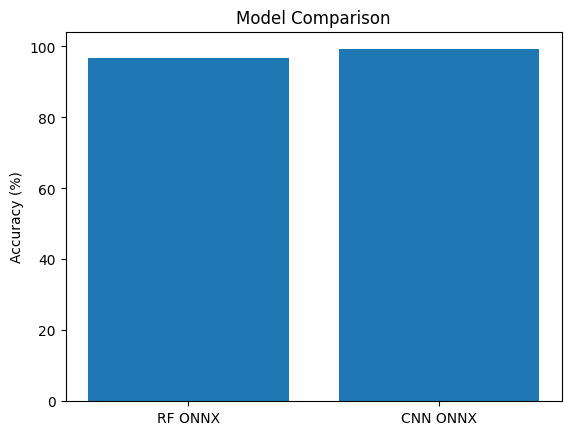

In [23]:
models = [
    "RF ONNX",
    "CNN ONNX"
]

accs = [
    96.8,
    99.2
]

plt.bar(models, accs)

plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")

plt.show()

# **Inference Time Visualization**

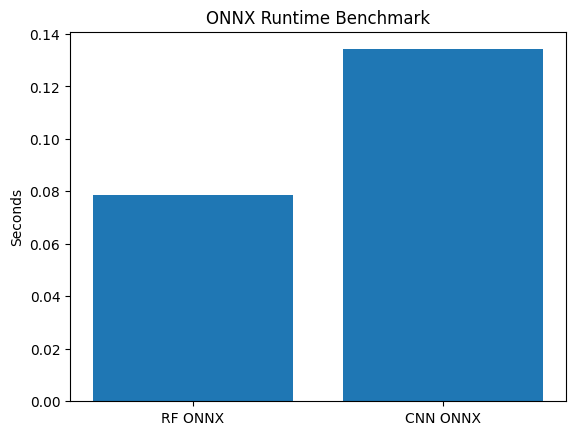

In [24]:
times = [
    rf_time,
    cnn_time
]

plt.bar(
    ["RF ONNX","CNN ONNX"],
    times
)

plt.ylabel("Seconds")
plt.title("ONNX Runtime Benchmark")

plt.show()